## Test plots for LQG Control Model

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from model.lqg_control_model import LQGController, LQGParams, Perturbation
import model_utils

%matplotlib inline

### Initialize LQG Controller and Parameters

In [2]:
# Initialize parameters and controller
params = LQGParams()
controller = LQGController(params)

# Create basis functions and feedforward weights
Phi = controller.make_default_basis(n_basis=8, width=10.0)
ff_weights = controller.make_default_ff_weights(n_basis=8)

print(f"Target: {params.target}")
print(f"Number of basis functions: {Phi.shape[1]}")

Target: [2. 2. 0. 0.]
Number of basis functions: 8


### 1. Baseline LQG Control Reach (No Perturbation)

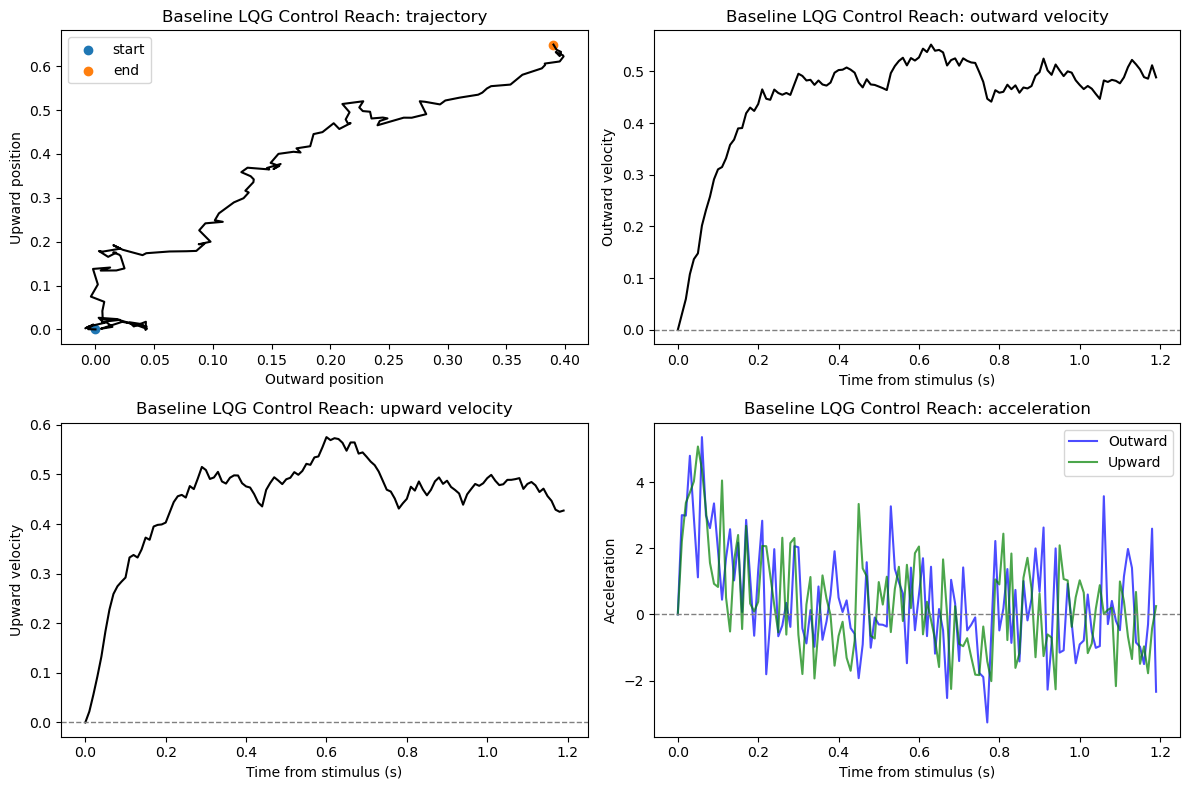

In [3]:
# Simulate baseline reach without perturbation
baseline = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=None,
    rng=np.random.default_rng(0)
)

# Plot baseline reach
model_utils.plot_reach(baseline, title="Baseline LQG Control Reach", params=params)

### 2. Mossy Fiber Perturbation

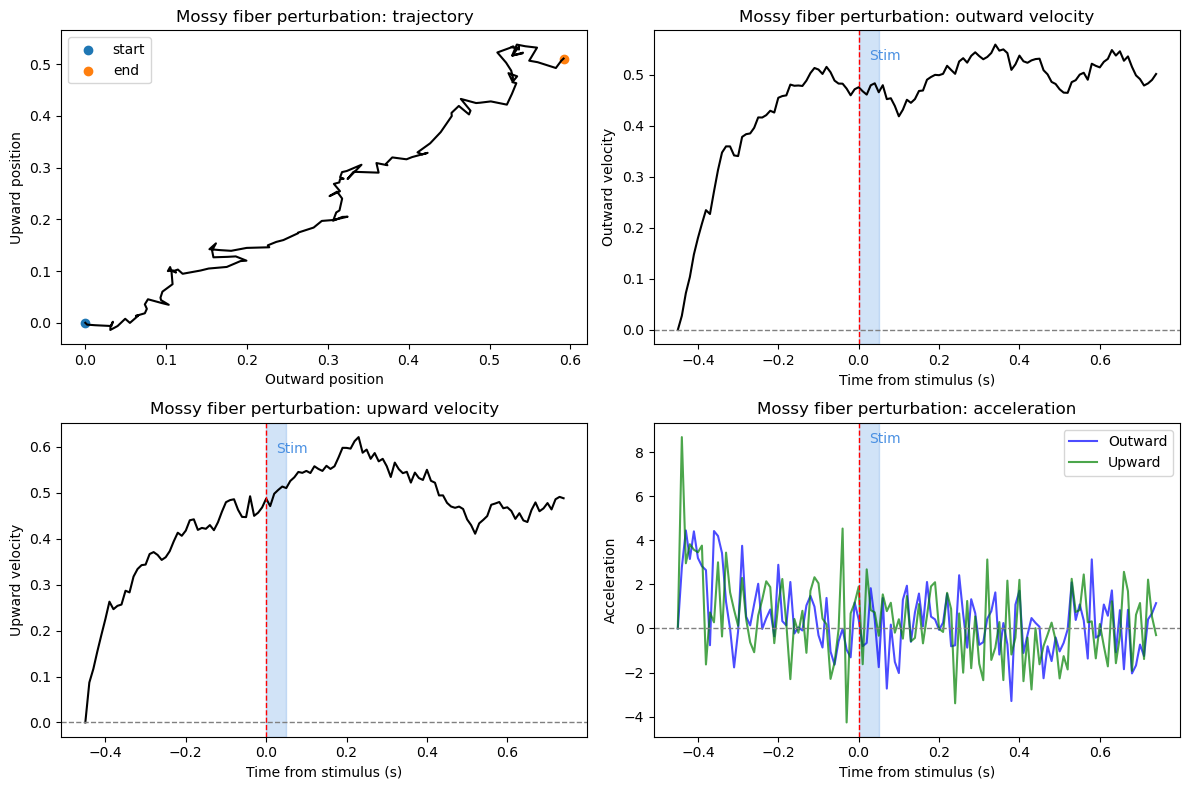

In [4]:
# Define mossy fiber perturbation
mossy_pert = Perturbation(
    kind='mossy',
    onset_idx=45,
    duration=5,
    observer_bias=np.array([0.0, 0.0, 0.9, 0.5])
)

# Simulate reach with mossy fiber perturbation
res_mossy = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=mossy_pert,
    rng=np.random.default_rng(3)
)

# Plot mossy fiber perturbation reach
model_utils.plot_reach(res_mossy, perturbation=mossy_pert, title="Mossy fiber perturbation", params=params)

### 3. General IntA Perturbation

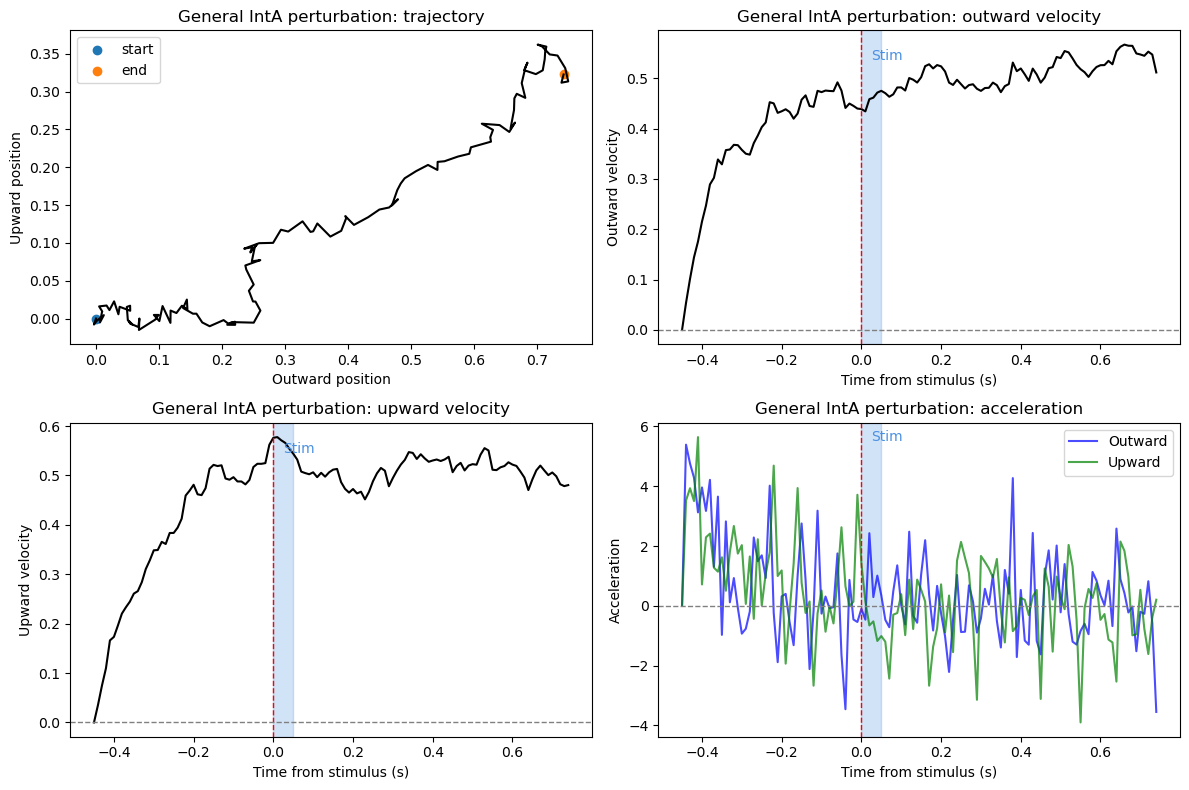

In [5]:
# Define general IntA perturbation
inta_general_pert = Perturbation(
    kind='inta_general',
    onset_idx=45,
    duration=5,
    pulse=np.array([-2.2, -1.0])
)

# Simulate reach with general IntA perturbation
res_inta_general = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=inta_general_pert,
    rng=np.random.default_rng(2)
)

# Plot general IntA perturbation reach
model_utils.plot_reach(res_inta_general, perturbation=inta_general_pert, title="General IntA perturbation", params=params)

### 4. IntA→RN Perturbation

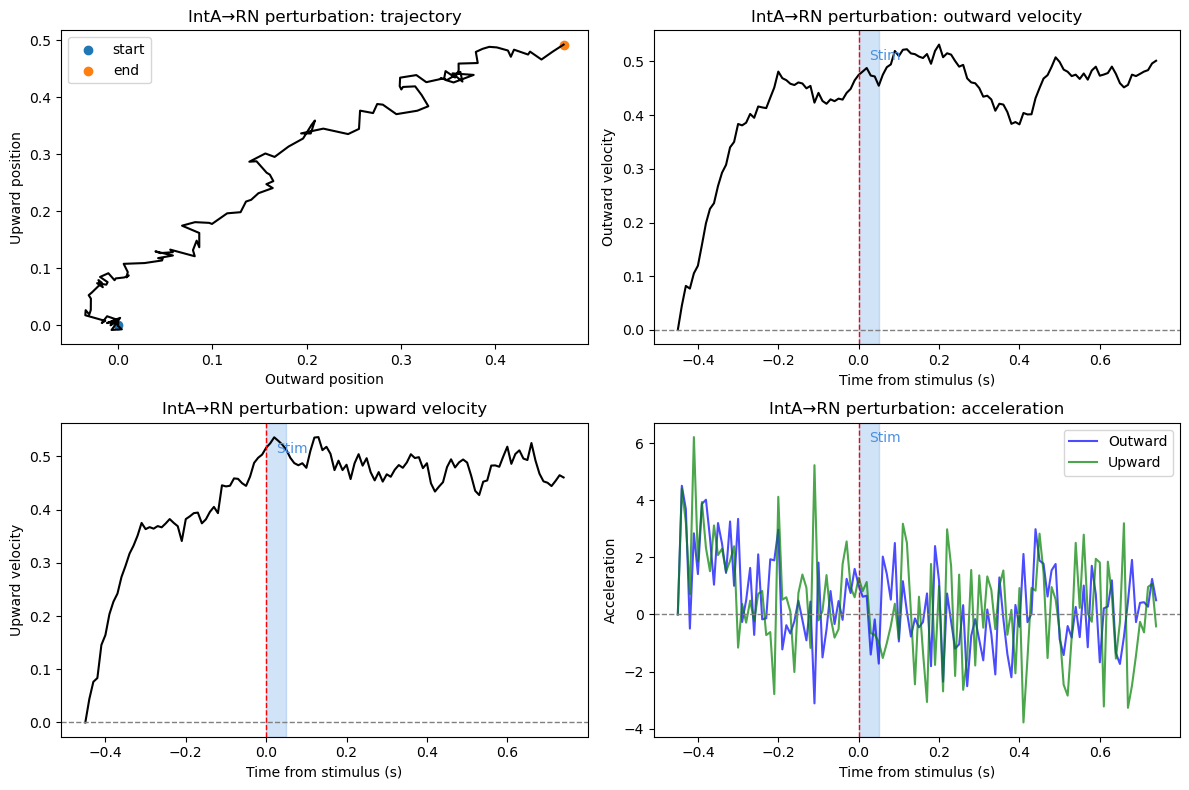

In [6]:
# Define IntA→RN perturbation
inta_rn_pert = Perturbation(
    kind='inta_rn',
    onset_idx=45,
    duration=5,
    pulse=np.array([-2.2, -1.0])
)

# Simulate reach with IntA→RN perturbation
res_inta_rn = controller.simulate_reach(
    Phi=Phi,
    ff_weights=ff_weights,
    perturbation=inta_rn_pert,
    rng=np.random.default_rng(1)
)

# Plot IntA→RN perturbation reach
model_utils.plot_reach(res_inta_rn, perturbation=inta_rn_pert, title="IntA→RN perturbation", params=params)

### 5. Behavior Summary Metrics

In [ ]:
# behavior metrics for all conditions
baseline_metrics = model_utils.compute_behavior_metrics(baseline, params.target)
inta_rn_metrics = model_utils.compute_behavior_metrics(res_inta_rn, params.target)
inta_general_metrics = model_utils.compute_behavior_metrics(res_inta_general, params.target)
mossy_metrics = model_utils.compute_behavior_metrics(res_mossy, params.target)

# make a pandas DataFrame 
metrics_df = pd.DataFrame({
    'Baseline': baseline_metrics,
    'IntA→RN Perturbation': inta_rn_metrics,
    'General IntA Perturbation': inta_general_metrics,
    'Mossy Fiber Perturbation': mossy_metrics
}).T

# show table
display(metrics_df.round(4))

Behavior Summary Metrics Across All Conditions



,endpoint_error,peak_outward_vel,min_outward_vel,rebound_magnitude,rebound_idx,peak_innovation,cost_J
Baseline,2.1015,0.5516,0.0,0.5516,63.0,0.1352,205844.2022
IntA→RN Perturbation,2.1462,0.5313,0.0,0.5313,65.0,0.1475,207771.3876
General IntA Perturbation,2.0968,0.5669,0.0,0.5669,111.0,0.1305,205147.6404
Mossy Fiber Perturbation,2.0498,0.5592,0.0,0.5592,79.0,1.0888,200514.7400
